[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_15/MFM_ch15_sem_partB/MFM_ch15_sem_partB.ipynb)

# MFM_ch15_sem_partB

Seminar 15, Part B: McNemar tests and bootstrap intervals for accuracy differences; training-data leakage of FinBERT; learning curves; clustered standard errors; event studies; the look-ahead test; prompt sensitivity.

*Modelling Financial Markets (MFM), Chapter 15: LLMs and Sentiment Analysis. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_15'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import io
import re
import sys
import json
import time
import zipfile
import subprocess
import urllib.request
for pkg, mod in (('pysentiment2', 'pysentiment2'), ('transformers', 'transformers')):
    try:
        __import__(mod)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Data, methods and tests

In [2]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

PHRASEBANK_URL = ('https://huggingface.co/datasets/takala/financial_phrasebank/resolve/main/data/'
                  'FinancialPhraseBank-v1.0.zip')
TWITTER_URL = 'https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment/resolve/main/'
FNSPID_URLS = ['https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/All_external.csv',
               'https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/nasdaq_exteral_data.csv']
LABELS = ['negative', 'neutral', 'positive']
TW_MAP = {0: 'negative', 1: 'positive', 2: 'neutral'}          # Bearish, Bullish, Neutral
AGREE = ['50Agree', '66Agree', '75Agree', 'AllAgree']

# actiuni americane cu stiri in FNSPID si preturi in data/market (Meta apare in FNSPID ca FB pana in 2022)
TICKERS = {'AAPL': 'AAPL.US', 'MSFT': 'MSFT.US', 'AMZN': 'AMZN.US', 'NVDA': 'NVDA.US', 'TSLA': 'TSLA.US',
           'GOOGL': 'GOOGL.US', 'GOOG': 'GOOGL.US', 'META': 'META.US', 'FB': 'META.US', 'JPM': 'JPM.US',
           'BAC': 'BAC.US', 'C': 'C.US', 'GS': 'GS.US', 'MS': 'MS.US', 'WFC': 'WFC.US', 'CSCO': 'CSCO.US',
           'GME': 'GME.US', 'MSTR': 'MSTR.US', 'COIN': 'COIN.US'}
LLM_SIZES = {'0.5B': 'Qwen/Qwen2.5-0.5B-Instruct', '1.5B': 'Qwen/Qwen2.5-1.5B-Instruct',
             '3B': 'Qwen/Qwen2.5-3B-Instruct', '7B': 'Qwen/Qwen2.5-7B-Instruct', '14B': 'Qwen/Qwen2.5-14B-Instruct'}
QWEN_RELEASE = '2024-09-19'          # publicarea ponderilor Qwen2.5
PROMPTS = {
    'P1': ('You classify the sentiment of financial news for investors. '
           'Answer with one word: positive, negative or neutral.', 'Headline: {x}\nSentiment:'),
    'P2': ('You are a financial analyst.', 'Is the following news good, bad or neutral for the stock price of the '
                                           'company it mentions? Answer with one word: positive, negative or '
                                           'neutral.\n\n{x}'),
    'P3': ('You are a helpful assistant.', 'Text: "{x}"\nWhat is the sentiment of this text? Reply positive, '
                                           'negative or neutral.'),
}


# =============================================================================
# DATE DE PIATA
# =============================================================================
def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def stock_returns(symbols, start='2009-01-01'):
    """Randamente simple zilnice (%) close-to-close pe pretul ajustat, pentru actiuni si SPY.
    Join pe preturi in zilele comune, apoi randamente."""
    px = pd.concat({s: read_market(s)['adjusted_close'] for s in symbols}, axis=1).loc[start:]
    return 100 * px.pct_change(fill_method=None)


# =============================================================================
# TEXTE ETICHETATE
# =============================================================================
def load_phrasebank():
    """Financial PhraseBank v1.0: 4,846 de propozitii din stiri financiare, etichetate de 16 adnotatori.
    Coloana 'agree': cel mai inalt prag de acord atins (50%, 66%, 75%, 100%)."""
    z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(PHRASEBANK_URL).read()))
    sets = {}
    for lvl in AGREE:
        raw = z.read(f'FinancialPhraseBank-v1.0/Sentences_{lvl}.txt').decode('latin-1')
        sets[lvl] = [tuple(l.rsplit('@', 1)) for l in raw.splitlines() if '@' in l]
    lookup = {lvl: set(v) for lvl, v in sets.items()}
    rows = []
    for text, lab in sets['50Agree']:
        agree = max([i for i, lvl in enumerate(AGREE) if (text, lab) in lookup[lvl]] or [0])
        rows.append((text.strip(), lab.strip(), AGREE[agree]))
    d = pd.DataFrame(rows, columns=['text', 'label', 'agree'])
    return d


def load_twitter(split='valid'):
    """Twitter Financial News Sentiment: titluri de stiri financiare publicate pe Twitter, 2022; train / valid."""
    d = pd.read_csv(TWITTER_URL + f'sent_{split}.csv')
    d['label'] = d['label'].map(TW_MAP)
    return d


# =============================================================================
# DICTIONARE
# =============================================================================
def load_dictionaries():
    """Liste de cuvinte: Loughran-McDonald (negative, pozitive, incertitudine) si Harvard IV-4 (Negativ, Positiv).
    Sursa: fisierele distribuite cu pachetul pysentiment2."""
    try:
        import pysentiment2
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pysentiment2'], check=True)
        import pysentiment2
    st = os.path.join(os.path.dirname(pysentiment2.__file__), 'static')
    lm = pd.read_csv(os.path.join(st, 'LM.csv'))
    lm['Word'] = lm['Word'].astype(str).str.upper()
    gi = pd.read_csv(os.path.join(st, 'HIV-4.csv'), dtype=str)
    gi['Entry'] = gi['Entry'].astype(str).str.upper().str.replace(r'#\d+$', '', regex=True)
    return {'LM_neg': set(lm.loc[lm['Negative'] > 0, 'Word']),
            'LM_pos': set(lm.loc[lm['Positive'] > 0, 'Word']),
            'LM_unc': set(lm.loc[lm['Uncertainty'] > 0, 'Word']),
            'GI_neg': set(gi.loc[gi['Negativ'].notna(), 'Entry']),
            'GI_pos': set(gi.loc[gi['Positiv'].notna(), 'Entry'])}


TOKEN = re.compile(r"[A-Za-z][A-Za-z'\-]*")


def tokens(text):
    """Cuvinte in majuscule, fara cifre si semne de punctuatie."""
    return [w.upper().strip("'-") for w in TOKEN.findall(str(text))]


def dict_counts(texts, pos, neg):
    """Numarul de cuvinte pozitive si negative din fiecare text."""
    P = np.array([sum(w in pos for w in tokens(t)) for t in texts])
    N = np.array([sum(w in neg for w in tokens(t)) for t in texts])
    return P, N


def dict_tone(texts, pos, neg):
    """Tonul: (P - N) / (P + N); 0 daca nu exista cuvinte din dictionar."""
    P, N = dict_counts(texts, pos, neg)
    return np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)


def tone_label(tone, band=0.0):
    return np.where(tone > band, 'positive', np.where(tone < -band, 'negative', 'neutral'))


def vader_compound(texts):
    """Scorul compus VADER (Hutto & Gilbert, 2014), in [-1, 1]."""
    import nltk
    try:
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
    except LookupError:
        nltk.download('vader_lexicon', quiet=True)
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
    return np.array([sia.polarity_scores(str(t))['compound'] for t in texts])


# =============================================================================
# MODELE DE LIMBAJ
# =============================================================================
def device():
    import torch
    if torch.cuda.is_available():
        return 'cuda'
    if torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'


def finbert_probs(texts, batch=64, name='ProsusAI/finbert'):
    """Probabilitatile FinBERT (negative, neutral, positive) pentru fiecare text."""
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    tok = AutoTokenizer.from_pretrained(name)
    m = AutoModelForSequenceClassification.from_pretrained(name).to(device()).eval()
    order = [m.config.label2id[l] for l in LABELS]
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch):
            b = tok([str(t) for t in texts[i:i + batch]], padding=True, truncation=True, max_length=96,
                    return_tensors='pt').to(m.device)
            out.append(m(**b).logits.float().softmax(-1)[:, order].cpu().numpy())
    return np.vstack(out)


def llm_load(size):
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM
    name = LLM_SIZES[size]
    tok = AutoTokenizer.from_pretrained(name)
    tok.padding_side = 'left'
    dev = device()
    dt = torch.float16 if dev != 'cpu' else torch.float32
    m = AutoModelForCausalLM.from_pretrained(name, dtype=dt).to(dev).eval()
    return tok, m


def llm_choice_probs(tok, m, system, user_texts, choices, batch=16):
    """Zero-shot: probabilitatile relative ale cuvintelor-raspuns (primul token al fiecaruia) la primul pas
    de generare, dupa sablonul de conversatie al modelului."""
    import torch
    ids = [tok.encode(w, add_special_tokens=False)[0] for w in choices]
    prompts = [tok.apply_chat_template([{'role': 'system', 'content': system}, {'role': 'user', 'content': u}],
                                       tokenize=False, add_generation_prompt=True) for u in user_texts]
    out = []
    with torch.no_grad():
        for i in range(0, len(prompts), batch):
            b = tok(prompts[i:i + batch], return_tensors='pt', padding=True).to(m.device)
            lg = m(**b).logits[:, -1, :][:, ids].float()
            out.append(lg.softmax(-1).cpu().numpy())
    return np.vstack(out)


def llm_sentiment(tok, m, texts, prompt='P1', batch=16):
    """Probabilitatile (negative, neutral, positive) date de un LLM zero-shot."""
    system, user = PROMPTS[prompt]
    return llm_choice_probs(tok, m, system, [user.format(x=str(t)) for t in texts], LABELS, batch)


def embed(texts, name='sentence-transformers/all-MiniLM-L6-v2', batch=128):
    """Embeddings de propozitie: media starilor ascunse (mean pooling), normalizate la lungimea 1."""
    import torch
    from transformers import AutoTokenizer, AutoModel
    tok = AutoTokenizer.from_pretrained(name)
    m = AutoModel.from_pretrained(name).to(device()).eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch):
            b = tok([str(t) for t in texts[i:i + batch]], padding=True, truncation=True, max_length=96,
                    return_tensors='pt').to(m.device)
            h = m(**b).last_hidden_state
            w = b['attention_mask'].unsqueeze(-1).float()
            e = (h * w).sum(1) / w.sum(1)
            out.append(torch.nn.functional.normalize(e, dim=1).cpu().numpy())
    return np.vstack(out)


def probs_label(P):
    """Eticheta cu probabilitatea maxima; coloanele sunt in ordinea LABELS."""
    return np.array(LABELS)[np.asarray(P).argmax(1)]


def net_score(P):
    """Scorul net de sentiment: P(pozitiv) - P(negativ), in [-1, 1]."""
    P = np.asarray(P)
    return P[:, 2] - P[:, 0]


# =============================================================================
# EVALUAREA CLASIFICARII
# =============================================================================
def confusion(y, yhat, labels=LABELS):
    return pd.crosstab(pd.Categorical(y, labels), pd.Categorical(yhat, labels), dropna=False,
                       rownames=['true'], colnames=['predicted'])


def macro_f1(y, yhat, labels=LABELS):
    y, yhat = np.asarray(y), np.asarray(yhat)
    f = []
    for l in labels:
        tp = np.sum((y == l) & (yhat == l))
        p = tp / max(np.sum(yhat == l), 1)
        r = tp / max(np.sum(y == l), 1)
        f.append(0 if p + r == 0 else 2 * p * r / (p + r))
    return float(np.mean(f))


def class_metrics(y, yhat, labels=LABELS):
    """Precizie, recall si F1 pe clase."""
    y, yhat = np.asarray(y), np.asarray(yhat)
    rows = {}
    for l in labels:
        tp = np.sum((y == l) & (yhat == l))
        p = tp / max(np.sum(yhat == l), 1)
        r = tp / max(np.sum(y == l), 1)
        rows[l] = {'precision': p, 'recall': r, 'f1': 0 if p + r == 0 else 2 * p * r / (p + r),
                   'support': int(np.sum(y == l))}
    return pd.DataFrame(rows).T


def boot_ci(y, yhat, stat, B=2000, seed=0, level=0.95):
    """Interval bootstrap (reesantionare i.i.d. a textelor) pentru o statistica a clasificarii."""
    rng = np.random.default_rng(seed)
    y, yhat = np.asarray(y), np.asarray(yhat)
    n = len(y)
    v = [stat(y[i], yhat[i]) for i in (rng.integers(0, n, n) for _ in range(B))]
    return tuple(np.quantile(v, [(1 - level) / 2, (1 + level) / 2]))


def acc(y, yhat):
    return float(np.mean(np.asarray(y) == np.asarray(yhat)))


def mcnemar(y, a, b):
    """Testul McNemar exact: compara doua clasificari pe aceleasi texte.
    n01: A greseste si B are dreptate; n10: invers."""
    y, a, b = map(np.asarray, (y, a, b))
    ca, cb = a == y, b == y
    n01, n10 = int(np.sum(~ca & cb)), int(np.sum(ca & ~cb))
    p = stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue if n01 + n10 > 0 else 1.0
    return n01, n10, float(p)


def diff_ci(y, a, b, B=2000, seed=0):
    """Interval bootstrap pentru diferenta de acuratete acc(B) - acc(A), pe aceleasi texte."""
    rng = np.random.default_rng(seed)
    y, a, b = map(np.asarray, (y, a, b))
    n = len(y)
    d = [np.mean(b[i] == y[i]) - np.mean(a[i] == y[i]) for i in (rng.integers(0, n, n) for _ in range(B))]
    return tuple(np.quantile(d, [0.025, 0.975]))


# =============================================================================
# STIRI DATATE SI SEMNALE
# =============================================================================
def load_fnspid(paths=None, tickers=TICKERS):
    """Titlurile FNSPID (ambele fisiere: surse externe si Nasdaq) pentru actiunile din TICKERS:
    data (UTC), titlu, simbol. Titlurile repetate (acelasi titlu, aceeasi actiune, aceeasi zi) apar o singura data."""
    out = []
    for src in (paths or FNSPID_URLS):
        for ch in pd.read_csv(src, usecols=['Date', 'Article_title', 'Stock_symbol'], chunksize=500_000, dtype=str,
                              on_bad_lines='skip'):
            out.append(ch[ch['Stock_symbol'].isin(tickers)])
    d = pd.concat(out).dropna()
    d['ts'] = pd.to_datetime(d['Date'], utc=True, errors='coerce')
    d = d.dropna(subset=['ts'])
    d['ticker'] = d['Stock_symbol'].map(lambda s: TICKERS[s].replace('.US', ''))
    d['title'] = d['Article_title'].str.strip()
    d = d.assign(dd=d['ts'].dt.date).drop_duplicates(['ticker', 'title', 'dd'])
    return d[['ts', 'ticker', 'title']].reset_index(drop=True)


def assign_trading_day(ts, days):
    """FNSPID da doar data publicarii (ora este 00:00 UTC pentru aproape toate titlurile): titlul datat d
    este atribuit primei zile de tranzactionare >= d. Ora din zi nu se cunoaste, deci stirea poate aparea
    si dupa inchiderea zilei d."""
    d0 = ts.dt.tz_convert('UTC').dt.tz_localize(None).dt.normalize()
    days = pd.DatetimeIndex(days).sort_values()
    pos = days.searchsorted(d0.values)
    ok = pos < len(days)
    out = pd.Series(pd.NaT, index=ts.index)
    out[ok] = days[pos[ok]]
    return out


def daily_panel(S, rets):
    """S: scoruri medii pe (zi, actiune), indexate (day, ticker). Adauga randamentul in exces fata de SPY
    in ziua stirii (r0), in urmatoarele doua zile (r1, r2) si in zilele -5..+5 (studiul de eveniment:
    rm5..rm1, r0, r1, r2, rp3..rp5). Cu date fara ora, r1 poate contine inca reactia la stire; primul randament
    sigur de tranzactionat este r2 (de la inchiderea zilei urmatoare)."""
    ex = rets.drop(columns='SPY').sub(rets['SPY'], axis=0)
    P = S.copy()
    for k in range(-5, 6):
        name = {0: 'r0', 1: 'r1', 2: 'r2'}.get(k, f'rp{k}' if k > 0 else f'rm{-k}')
        sh = ex.shift(-k).stack()
        sh.index.names = ['day', 'ticker']
        P = P.join(sh.rename(name), how='left')
    return P.dropna(subset=['r0', 'r1', 'r2'])


def cluster_ols(y, x, groups):
    """OLS y = a + b x cu erori standard obisnuite si grupate pe zile (Petersen, 2009)."""
    X = np.column_stack([np.ones(len(x)), x])
    y = np.asarray(y, float)
    XtX = np.linalg.inv(X.T @ X)
    b = XtX @ X.T @ y
    e = y - X @ b
    n, k = X.shape
    V_ols = XtX * (e @ e) / (n - k)
    idx_g = pd.Series(np.arange(n)).groupby(np.asarray(groups)).apply(list)
    meat = sum(np.outer(X[i].T @ e[i], X[i].T @ e[i]) for i in idx_g)
    G = len(idx_g)
    V_cl = XtX @ meat @ XtX * G / (G - 1) * (n - 1) / (n - k)
    return {'b': b[1], 'a': b[0], 'se_ols': np.sqrt(V_ols[1, 1]), 'se_cl': np.sqrt(V_cl[1, 1]),
            't_ols': b[1] / np.sqrt(V_ols[1, 1]), 't_cl': b[1] / np.sqrt(V_cl[1, 1]),
            'r2': 1 - (e @ e) / np.sum((y - y.mean()) ** 2), 'n': n, 'G': G}


def nw_t(x, lags=None):
    """Media si statistica t cu varianta Newey-West (HAC)."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    n = len(x)
    L = lags if lags is not None else int(np.floor(4 * (n / 100) ** (2 / 9)))
    u = x - x.mean()
    v = u @ u / n
    for l in range(1, L + 1):
        v += 2 * (1 - l / (L + 1)) * (u[l:] @ u[:-l]) / n
    return x.mean(), x.mean() / np.sqrt(v / n)


def block_boot_mean(x, B=2000, block=10, seed=0):
    """Interval bootstrap pe blocuri mobile pentru media unei serii zilnice."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    n = len(x)
    nb = int(np.ceil(n / block))
    v = []
    for _ in range(B):
        st = rng.integers(0, n - block + 1, nb)
        v.append(np.concatenate([x[s:s + block] for s in st])[:n].mean())
    return tuple(np.quantile(v, [0.025, 0.975]))


def signal_portfolio(P, col, days, cost_bp=0.0, band=0.0, ret='r2'):
    """Strategia zilnica: pentru fiecare actiune cu stiri (|scor| > band) luam pozitia sign(scor), acoperita cu SPY,
    ponderi egale; castigul este randamentul in exces din coloana ret (implicit r2: pozitia se deschide la
    inchiderea zilei de dupa stire, cand stirea este sigur publica). Zilele fara pozitii au randament 0.
    Costul: cost_bp puncte de baza pe fiecare tranzactie (actiune si SPY, la intrare si la iesire: 4 x cost)."""
    q = P[P[col].abs() > band]
    lag = {'r0': 0, 'r1': 1, 'r2': 2}[ret]
    pos_day = pd.DatetimeIndex(days)
    idx = pos_day.get_indexer(q.index.get_level_values('day'))
    ok = (idx >= 0) & (idx + lag < len(pos_day))
    q = q[ok]
    earn_day = pos_day[idx[ok] + lag]
    x = pd.Series(np.sign(q[col].values) * q[ret].values, index=earn_day)
    grp = x.groupby(level=0)
    R = pd.DataFrame({'gross': grp.mean(), 'k': grp.size()}).reindex(pos_day).fillna(0.0)
    R['net'] = R['gross'] - np.where(R['k'] > 0, 4 * cost_bp / 100, 0.0)
    return R


def sharpe(x, ppy=252):
    x = np.asarray(x, float)
    return float(np.sqrt(ppy) * x.mean() / x.std(ddof=1))

## Style and helpers

In [3]:
# Stil standard MFM: transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Crimson = '#DC3545'
Teal = '#17A2B8'
Magenta = '#D63384'
Brown = '#795548'
Gray = '#7F7F7F'          # doar linii de referinta
LightGray = '#DADADA'     # doar benzi

LAB_COL = {'negative': IDAred, 'neutral': Amber, 'positive': Forest}
METHODS = ['GI', 'VADER', 'LM', 'TF-IDF + LR', 'MiniLM + LR', 'FinBERT', 'Qwen 0.5B', 'Qwen 1.5B', 'Qwen 3B',
           'Qwen 7B', 'Qwen 14B']
M_COL = {'GI': Brown, 'VADER': Amber, 'LM': Orange, 'TF-IDF + LR': Teal, 'MiniLM + LR': Magenta,
         'FinBERT': MainBlue, 'Qwen 0.5B': '#F4A6A6', 'Qwen 1.5B': '#E86A6A', 'Qwen 3B': Crimson,
         'Qwen 7B': IDAred, 'Qwen 14B': '#7A0000'}
SIZES_B = {'0.5B': 0.5, '1.5B': 1.5, '3B': 3.0, '7B': 7.0, '14B': 14.0}
SCORE_LBL = {'lm': 'Loughran-McDonald tone', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
SCORE_COL = {'lm': Orange, 'finbert': MainBlue, 'qwen': IDAred}
EVENT_COLS = ['rm5', 'rm4', 'rm3', 'rm2', 'rm1', 'r0', 'r1', 'r2', 'rp3', 'rp4', 'rp5']
PERIODS = (('2010', '2015'), ('2016', '2019'), ('2020', '2021'), ('2022', '2023'))


RES = {}
FC_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_15/'
FC_DIR = next((d for d in ('.', '..', 'Quantlets/Ch_15', '../Quantlets/Ch_15', '../../Quantlets/Ch_15')
               if os.path.exists(os.path.join(d, 'ch15_twitter_scores.csv'))), None)


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def load_csv(name, **kw):
    """Tabelul de scoruri ch15_*.csv (produs de run_scores), local sau din repository."""
    path = os.path.join(FC_DIR, name) if FC_DIR else FC_RAW + name
    return pd.read_csv(path, **kw)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0):
    """O singura legenda pentru toata figura, sub panouri."""
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def predictions(d):
    """Eticheta prezisa de fiecare metoda (coloanele ch15_*_scores.csv)."""
    v = d['vader'].values
    out = {'GI': tone_label(d['GI_tone'].values), 'LM': tone_label(d['LM_tone'].values),
           'VADER': np.where(v >= 0.05, 'positive', np.where(v <= -0.05, 'negative', 'neutral')),
           'TF-IDF + LR': probs_label(d[[f'tfidf_{l}' for l in LABELS]].values),
           'MiniLM + LR': probs_label(d[[f'emb_{l}' for l in LABELS]].values),
           'FinBERT': probs_label(d[[f'finbert_{l}' for l in LABELS]].values)}
    for s in SIZES_B:
        out[f'Qwen {s}'] = probs_label(d[[f'qwen{s}_{l}' for l in LABELS]].values)
    return out


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items() if not isinstance(v, pd.DataFrame)}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    return o

LAB_COL = {'negative': '#CD0000', 'neutral': '#B5853F', 'positive': '#2E7D32'}
METHODS = ['GI', 'VADER', 'LM', 'TF-IDF + LR', 'MiniLM + LR', 'FinBERT', 'Qwen 0.5B', 'Qwen 1.5B', 'Qwen 3B', 'Qwen 7B', 'Qwen 14B']
M_COL = {'GI': '#795548', 'VADER': '#B5853F', 'LM': '#E67E22', 'TF-IDF + LR': '#17A2B8', 'MiniLM + LR': '#D63384', 'FinBERT': '#1A3A6E', 'Qwen 0.5B': '#F4A6A6', 'Qwen 1.5B': '#E86A6A', 'Qwen 3B': '#DC3545', 'Qwen 7B': '#CD0000', 'Qwen 14B': '#7A0000'}
SIZES_B = {'0.5B': 0.5, '1.5B': 1.5, '3B': 3.0, '7B': 7.0, '14B': 14.0}
SCORE_LBL = {'lm': 'Loughran-McDonald tone', 'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B'}
SCORE_COL = {'lm': '#E67E22', 'finbert': '#1A3A6E', 'qwen': '#CD0000'}
EVENT_COLS = ['rm5', 'rm4', 'rm3', 'rm2', 'rm1', 'r0', 'r1', 'r2', 'rp3', 'rp4', 'rp5']
PERIODS = (('2010', '2015'), ('2016', '2019'), ('2020', '2021'), ('2022', '2023'))

## Sentiment scores

In [4]:
HERE = '.'
SEED = 15
MONTHS = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


def tick(msg, t0):
    print(f'   {msg}: {time.time() - t0:.0f}s', flush=True)


def dict_cols(d, texts, D):
    for k in ('LM', 'GI'):
        P, N = dict_counts(texts, D[k + '_pos'], D[k + '_neg'])
        d[f'{k}_pos'], d[f'{k}_neg'] = P, N
        d[f'{k}_tone'] = np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)
    d['vader'] = vader_compound(texts)


def texts_block():
    t0 = time.time()
    pb, tw, tr = load_phrasebank(), load_twitter('valid'), load_twitter('train')
    D = load_dictionaries()
    out = {'pb': pb[['label', 'agree']].copy(), 'tw': tw[['label']].copy()}
    src = {'pb': pb['text'].tolist(), 'tw': tw['text'].tolist()}
    for k in out:
        dict_cols(out[k], src[k], D)
    tick('dictionaries', t0)
    for k in out:
        P = finbert_probs(src[k])
        for j, l in enumerate(LABELS):
            out[k][f'finbert_{l}'] = P[:, j]
    tick('FinBERT', t0)
    for size in LLM_SIZES:
        tok, m = llm_load(size)
        for k in out:
            prompts = ['P1', 'P2', 'P3'] if (k == 'tw' and size in ('1.5B', '7B', '14B')) else ['P1']
            for pr in prompts:
                t1 = time.time()
                P = llm_sentiment(tok, m, src[k], pr)
                tag = f'qwen{size}' + ('' if pr == 'P1' else f'_{pr}')
                for j, l in enumerate(LABELS):
                    out[k][f'{tag}_{l}'] = P[:, j]
                out[k].attrs[f'time_{tag}'] = (time.time() - t1) / len(src[k])
        del m
        try:
            import torch
            torch.mps.empty_cache()
        except Exception:
            pass
        tick(f'Qwen {size}', t0)
    # embeddings + regresie logistica, invatate pe setul de antrenare Twitter
    from sklearn.linear_model import LogisticRegression
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import PCA
    Etr, Etw, Epb = embed(tr['text'].tolist()), embed(src['tw']), embed(src['pb'])
    clf = LogisticRegression(C=4.0, max_iter=3000).fit(Etr, tr['label'])
    for k, E in (('tw', Etw), ('pb', Epb)):
        P = clf.predict_proba(E)[:, [list(clf.classes_).index(l) for l in LABELS]]
        for j, l in enumerate(LABELS):
            out[k][f'emb_{l}'] = P[:, j]
    tf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(tr['text'])
    clf2 = LogisticRegression(C=8.0, max_iter=3000).fit(tf.transform(tr['text']), tr['label'])
    for k in out:
        P = clf2.predict_proba(tf.transform(src[k]))[:, [list(clf2.classes_).index(l) for l in LABELS]]
        for j, l in enumerate(LABELS):
            out[k][f'tfidf_{l}'] = P[:, j]
    pc = PCA(2, random_state=SEED).fit(Etr)
    xy = pc.transform(Etw)
    out['tw']['pc1'], out['tw']['pc2'] = xy[:, 0], xy[:, 1]
    tick('embeddings', t0)
    # curba de invatare: cate etichete sunt necesare?
    rng = np.random.default_rng(SEED)
    rows = []
    for n in (100, 200, 400, 800, 1600, 3200, 6400, len(tr)):
        for rep in range(10 if n < len(tr) else 1):
            idx = rng.choice(len(tr), n, replace=False) if n < len(tr) else np.arange(len(tr))
            y = tr['label'].values[idx]
            if len(set(y)) < 3:
                continue
            a = LogisticRegression(C=4.0, max_iter=3000).fit(Etr[idx], y).predict(Etw)
            tfn = TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True).fit(tr['text'].values[idx])
            b = LogisticRegression(C=8.0, max_iter=3000).fit(tfn.transform(tr['text'].values[idx]), y).predict(
                tfn.transform(src['tw']))
            rows.append({'n': n, 'rep': rep, 'emb_acc': acc(tw['label'], a), 'emb_f1': macro_f1(tw['label'], a),
                         'tfidf_acc': acc(tw['label'], b), 'tfidf_f1': macro_f1(tw['label'], b)})
    pd.DataFrame(rows).to_csv(os.path.join(HERE, 'ch15_learning_curve.csv'), index=False)
    for k, name in (('pb', 'ch15_phrasebank_scores.csv'), ('tw', 'ch15_twitter_scores.csv')):
        out[k].round(6).to_csv(os.path.join(HERE, name), index_label='id')
    times = {**out['tw'].attrs}
    pd.Series(times).to_csv(os.path.join(HERE, 'ch15_llm_time.csv'), header=['sec_per_text'])
    tick('texts done', t0)


def memory_block(sizes=('1.5B', '7B', '14B')):
    """Directia lunara a S&P 500 (2000-2026) si directia zilnica a Apple, intrebate fara niciun context."""
    t0 = time.time()
    px = read_market('GSPC.INDX')['close']
    mon = px.resample('ME').last()
    mret = 100 * mon.pct_change().dropna().loc['2000-01':'2026-08']
    aapl = read_market('AAPL.US')['adjusted_close']
    dret = 100 * aapl.pct_change().dropna()
    rng = np.random.default_rng(SEED)
    pre = dret.loc['2010-01-01':'2023-12-31']
    post = dret.loc['2024-10-01':]
    days = pd.concat([pre.iloc[np.sort(rng.choice(len(pre), 500, replace=False))], post])
    dm = pd.DataFrame({'ret': mret})
    dd = pd.DataFrame({'ret': days})
    sys_m = 'You are a financial historian. Answer with one word: rise or fall.'
    q_m = [f'Did the S&P 500 index rise or fall during {MONTHS[d.month - 1]} {d.year}?' for d in dm.index]
    sys_d = 'You are a financial historian. Answer with one word: higher or lower.'
    q_d = [f'Did Apple (AAPL) stock close higher or lower on {d.strftime("%A")}, {MONTHS[d.month - 1]} {d.day}, '
           f'{d.year} than on the previous trading day?' for d in dd.index]
    for size in sizes:
        tok, m = llm_load(size)
        dm[f'qwen{size}'] = llm_choice_probs(tok, m, sys_m, q_m, ['rise', 'fall'])[:, 0]
        dd[f'qwen{size}'] = llm_choice_probs(tok, m, sys_d, q_d, ['higher', 'lower'])[:, 0]
        del m
        tick(f'memory {size}', t0)
    dm.round(6).to_csv(os.path.join(HERE, 'ch15_memory_monthly.csv'), index_label='month')
    dd.round(6).to_csv(os.path.join(HERE, 'ch15_memory_daily.csv'), index_label='date')


def news_block(paths=None, llm='7B', batch=64):
    """Scoruri pentru fiecare titlu, apoi medii pe (zi de tranzactionare, actiune)."""
    t0 = time.time()
    news = load_fnspid(paths)
    tick(f'FNSPID {len(news)} headlines', t0)
    rets = stock_returns(sorted(set(TICKERS.values())) + ['SPY.US'], start='2009-01-01')
    rets.columns = [c.replace('.US', '') for c in rets.columns]
    news['day'] = assign_trading_day(news['ts'], rets.index)
    news = news.dropna(subset=['day'])
    news = news[news['day'] >= '2009-06-01']
    D = load_dictionaries()
    P, N = dict_counts(news['title'].tolist(), D['LM_pos'], D['LM_neg'])
    news['lm'] = np.where(P + N > 0, (P - N) / np.maximum(P + N, 1), 0.0)
    news['lm_hit'] = (P + N > 0).astype(int)
    F = finbert_probs(news['title'].tolist(), batch=256)
    news['finbert'] = net_score(F)
    news['finbert_lab'] = F.argmax(1) - 1
    tick('FinBERT', t0)
    tok, m = llm_load(llm)
    Q = llm_sentiment(tok, m, news['title'].tolist(), 'P1', batch=batch)
    news['qwen'] = net_score(Q)
    tick(f'Qwen {llm}', t0)
    grp = news.groupby(['day', 'ticker'])
    daily = grp[['finbert', 'lm', 'qwen']].mean()
    daily['n'] = grp.size()
    daily['lm_hit'] = grp['lm_hit'].mean()
    daily.round(6).to_csv(os.path.join(HERE, 'ch15_news_daily.csv'))
    by_year = news.groupby([news['day'].dt.year, 'ticker']).size().unstack(fill_value=0)
    by_year.to_csv(os.path.join(HERE, 'ch15_news_counts.csv'))
    hour = news['ts'].dt.tz_convert('UTC').dt.hour.value_counts().reindex(range(24), fill_value=0)
    exact = ((news['ts'].dt.hour == 0) & (news['ts'].dt.minute == 0) & (news['ts'].dt.second == 0)).mean()
    pd.DataFrame({'n': hour, 'share_midnight': exact}).to_csv(os.path.join(HERE, 'ch15_news_hours.csv'))
    # scorurile titlurilor individuale (fara text) pentru comparatia metodelor
    news[['day', 'ticker', 'finbert', 'finbert_lab', 'lm', 'lm_hit', 'qwen']].round(5).to_csv(
        os.path.join(HERE, 'ch15_news_headlines.csv.gz'), index=False, compression='gzip')
    tick('news done', t0)

In [5]:
# True: refacerea tuturor scorurilor (descarcarea modelelor FinBERT, MiniLM si Qwen2.5 0.5B-14B si a titlurilor
# FNSPID; ore de calcul fara GPU); False: tabelele ch15_*.csv publicate in folderul Capitolului 15.
RECOMPUTE = False
if RECOMPUTE:
    texts_block()
    memory_block()
    news_block()
    FC_DIR = '.'

## Analysis

In [6]:
def b_pairs(a, b, data='tw'):
    d = load_csv('ch15_twitter_scores.csv' if data == 'tw' else 'ch15_phrasebank_scores.csv')
    y = d['label'].values
    pr = predictions(d)
    n01, n10, p = mcnemar(y, pr[a], pr[b])
    lo, hi = diff_ci(y, pr[a], pr[b])
    return {'acc_a': acc(y, pr[a]), 'acc_b': acc(y, pr[b]), 'diff': acc(y, pr[b]) - acc(y, pr[a]),
            'lo': lo, 'hi': hi, 'n01': n01, 'n10': n10, 'p': p,
            'ci_a': boot_ci(y, pr[a], acc), 'ci_b': boot_ci(y, pr[b], acc)}


def b_leakage():
    """B3: acuratetea pe datele de antrenare ale FinBERT (PhraseBank) si pe date noi (Twitter)."""
    pb = load_csv('ch15_phrasebank_scores.csv')
    tw = load_csv('ch15_twitter_scores.csv')
    out = {}
    for m in ('FinBERT', 'Qwen 7B', 'LM', 'MiniLM + LR'):
        r = {}
        for name, d in (('pb_all', pb[pb['agree'] == 'AllAgree']), ('pb', pb), ('tw', tw)):
            yh = predictions(d)[m]
            r[name] = {'acc': acc(d['label'], yh), 'ci': boot_ci(d['label'].values, yh, acc),
                       'f1': macro_f1(d['label'], yh)}
        out[m] = r
    return out


def b_learning():
    lc = load_csv('ch15_learning_curve.csv')
    tw = load_csv('ch15_twitter_scores.csv')
    fb = acc(tw['label'], predictions(tw)['FinBERT'])
    q7 = acc(tw['label'], predictions(tw)['Qwen 7B'])
    m = lc.groupby('n')[['emb_acc', 'tfidf_acc']].agg(['mean', 'std'])
    first_emb = next((int(n) for n in m.index if m.loc[n, ('emb_acc', 'mean')] > fb), None)
    first_tf = next((int(n) for n in m.index if m.loc[n, ('tfidf_acc', 'mean')] > fb), None)
    return {'fb': fb, 'q7': q7, 'first_emb': first_emb, 'first_tfidf': first_tf,
            'table': {int(n): {'emb': float(r[('emb_acc', 'mean')]), 'emb_sd': float(r[('emb_acc', 'std')]),
                               'tfidf': float(r[('tfidf_acc', 'mean')])} for n, r in m.iterrows()}}


def b_cluster(P):
    """B5: aceeasi regresie, erori standard OLS vs grupate pe zile vs grupate pe actiuni."""
    out = {}
    for c in ('finbert', 'lm', 'qwen'):
        for y in ('r0', 'r1', 'r2'):
            a = cluster_ols(P[y].values, P[f'z_{c}'].values, P.index.get_level_values('day'))
            b = cluster_ols(P[y].values, P[f'z_{c}'].values, P.index.get_level_values('ticker'))
            out[f'{c}|{y}'] = {'b_bp': 100 * a['b'], 'se_ols': 100 * a['se_ols'], 'se_day': 100 * a['se_cl'],
                               'se_tic': 100 * b['se_cl'], 't_ols': a['t_ols'], 't_day': a['t_cl'],
                               't_tic': b['t_cl'], 'n': a['n'], 'G_day': a['G'], 'G_tic': b['G'], 'r2': a['r2']}
    return out


def fig_cluster(B5):
    fig, ax = plt.subplots(figsize=(6.4, 2.9))
    x = np.arange(3)
    for k, (se, c, lab) in enumerate((('se_ols', Amber, 'OLS standard errors'),
                                      ('se_day', MainBlue, 'Clustered by day'),
                                      ('se_tic', Purple, 'Clustered by stock'))):
        b = [B5[f'{s}|r0']['b_bp'] for s in ('finbert', 'qwen', 'lm')]
        e = [1.96 * B5[f'{s}|r0'][se] for s in ('finbert', 'qwen', 'lm')]
        ax.errorbar(x + (k - 1) * 0.2, b, yerr=e, fmt='o', color=c, capsize=3, ms=4, label=lab)
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(['FinBERT', 'Qwen2.5-7B', 'Loughran-McDonald'])
    ax.set_ylabel('Same-day excess return per 1 s.d. (bp)')
    legend_outside_bottom(ax, ncol=3, y=-0.16)
    save_fig('ch15_sem_cluster')


def event_groups(x):
    """Grupurile studiului de eveniment: tercila cea mai negativa si cea mai pozitiva a scorului zilnic. Daca cele
    doua praguri coincid (tonul LM este exact 0 in aproape jumatate din zilele-actiune), grupurile disjuncte sunt
    scor < prag si scor > prag, iar zilele egale cu pragul sunt excluse."""
    q1, q2 = x.quantile([1 / 3, 2 / 3])
    if q1 >= q2:
        return x < q1, x > q2
    return x <= q1, x >= q2


def b_event(P, col):
    cols = EVENT_COLS
    neg, pos = event_groups(P[col])
    out = {'zero_share': float((P[col] == 0).mean())}
    for grp, sel in (('neg', neg), ('pos', pos)):
        X = P.loc[sel, cols].groupby(level='day').mean().fillna(0)
        car = X.cumsum(axis=1)
        pre = X[['rm5', 'rm4', 'rm3', 'rm2', 'rm1']].sum(1)
        post = X[['r2', 'rp3', 'rp4', 'rp5']].sum(1)
        out[grp] = {'car_m1': float(car['rm1'].mean()), 'car_0': float(car['r0'].mean()),
                    'day0': float(X['r0'].mean()), 'day0_t': nw_t(X['r0'])[1],
                    'day1': float(X['r1'].mean()), 'day1_t': nw_t(X['r1'])[1],
                    'pre': float(pre.mean()), 'pre_t': nw_t(pre)[1],
                    'post': float(post.mean()), 'post_t': nw_t(post)[1], 'n_days': len(X), 'n_obs': int(sel.sum())}
    return out


def b_memory():
    """B7: AUC pentru directia lunara a S&P 500, inainte si dupa publicarea ponderilor Qwen2.5."""
    mm = load_csv('ch15_memory_monthly.csv', index_col=0, parse_dates=True)
    out = {}
    for s in ('1.5B', '7B', '14B'):
        r = {}
        for per, sel in (('pre', mm.index <= '2024-08-31'), ('post', mm.index >= '2024-10-01')):
            p, u = mm.loc[sel, f'qwen{s}'].values, (mm.loc[sel, 'ret'] > 0).values
            lo, hi = boot_auc(p, u)
            r[per] = {'auc': auc(p, u), 'lo': lo, 'hi': hi, 'n': int(sel.sum()), 'n_up': int(u.sum()),
                      'mean_up': float(p[u].mean()), 'mean_down': float(p[~u].mean())}
        out[s] = r
    # permutare: AUC sub ipoteza nula, perioada de dinainte (14B)
    rng = np.random.default_rng(1)
    pre = mm.loc[:'2024-08-31']
    p, u = pre['qwen14B'].values, (pre['ret'] > 0).values
    null = [auc(p, rng.permutation(u)) for _ in range(2000)]
    out['perm_p'] = float(np.mean(np.array(null) >= auc(p, u)))
    return out


def b_prompts():
    tw = load_csv('ch15_twitter_scores.csv')
    y = tw['label'].values
    out = {}
    for s in ('7B', '14B'):
        labs = {p: probs_label(tw[[f'qwen{s}{"" if p == "P1" else "_" + p}_{l}' for l in LABELS]].values)
                for p in ('P1', 'P2', 'P3')}
        r = {p: {'acc': acc(y, v), 'ci': boot_ci(y, v, acc), 'neutral': float(np.mean(v == 'neutral'))}
             for p, v in labs.items()}
        n01, n10, pv = mcnemar(y, labs['P1'], labs['P3'])
        r['p13'] = {'n01': n01, 'n10': n10, 'p': pv, 'agree': float(np.mean(labs['P1'] == labs['P3']))}
        r['agree_all'] = float(np.mean((labs['P1'] == labs['P2']) & (labs['P1'] == labs['P3'])))
        out[s] = r
    return out


def news_panel():
    daily = load_csv('ch15_news_daily.csv', parse_dates=['day']).set_index(['day', 'ticker'])
    syms = sorted(set(TICKERS.values()))
    rets = stock_returns(syms + ['SPY.US'], start='2009-01-01')
    rets.columns = [c.replace('.US', '') for c in rets.columns]
    rets = rets.loc[:'2023-12-31']
    P = daily_panel(daily, rets)
    for c in SCORE_LBL:
        P[f'z_{c}'] = (P[c] - P[c].mean()) / P[c].std()
    return P, rets


def auc(p, up):
    p, up = np.asarray(p), np.asarray(up, bool)
    return float(stats_auc(p[up], p[~up]))


def stats_auc(a, b):
    from scipy.stats import mannwhitneyu
    if len(a) == 0 or len(b) == 0:
        return np.nan
    return mannwhitneyu(a, b).statistic / (len(a) * len(b))


def boot_auc(p, up, B=2000, seed=0):
    rng = np.random.default_rng(seed)
    p, up = np.asarray(p), np.asarray(up, bool)
    v = []
    for _ in range(B):
        i = rng.integers(0, len(p), len(p))
        if up[i].all() or (~up[i]).all():
            continue
        v.append(stats_auc(p[i][up[i]], p[i][~up[i]]))
    return tuple(np.quantile(v, [0.025, 0.975]))


def fig_pairs(key='B1', names=('LM', 'FinBERT'), name='ch15_sem_b1_pairs'):
    """B1/B2: acuratetea celor doi clasificatori cu CI bootstrap, diferenta pe perechi cu CI si cazurile discordante."""
    b = S[key]
    fig, (ax, cx, bx) = plt.subplots(1, 3, figsize=(7.0, 2.4), gridspec_kw={'width_ratios': [1.3, 1.1, 1.0]})
    for yy, v, ci, col in ((1, b['acc_a'], b['ci_a'], Orange), (0, b['acc_b'], b['ci_b'], MainBlue)):
        ax.errorbar(100 * v, yy, xerr=[[100 * (v - ci[0])], [100 * (ci[1] - v)]], fmt='o', color=col, capsize=3, ms=5)
    ax.set_yticks([1, 0])
    ax.set_yticklabels(list(names))
    ax.set_ylim(-0.6, 1.6)
    ax.set_xlabel('Accuracy (%), 95% bootstrap CI')
    d = 100 * b['diff']
    cx.errorbar(d, 0, xerr=[[d - 100 * b['lo']], [100 * b['hi'] - d]], fmt='s', color=IDAred, capsize=3, ms=5)
    cx.axvline(0, color=Gray, lw=0.8, ls='--')
    cx.set_yticks([0])
    cx.set_yticklabels([f'{names[1]} $-$\n{names[0]}'], fontsize=7)
    cx.set_ylim(-1, 1)
    cx.set_xlabel('Paired difference (pp), 95% CI')
    n01, n10 = b['n01'], b['n10']
    bx.bar([0, 1], [n01, n10], color=[MainBlue, Orange], width=0.6)
    bx.axhline((n01 + n10) / 2, color=Gray, lw=0.8, ls='--')
    bx.set_xticks([0, 1])
    bx.set_xticklabels([f'$n_{{01}}$ = {n01}', f'$n_{{10}}$ = {n10}'])
    bx.set_ylim(0, 1.18 * max(n01, n10))
    bx.set_ylabel('Discordant headlines')
    bx.set_xlabel('Dashed line: $H_0$')
    fig.tight_layout()
    save_fig(name)


def fig_leakage():
    """B3: acuratetea pe tot Financial PhraseBank si pe Twitter, pentru patru clasificatori."""
    B3 = S['B3']
    ms = ['FinBERT', 'Qwen 7B', 'LM', 'MiniLM + LR']
    labs = ['FinBERT', 'Qwen2.5-7B', 'LM', 'MiniLM + LR']
    fig, ax = plt.subplots(figsize=(6.4, 2.6))
    for k, m in enumerate(ms):
        a, b = 100 * B3[m]['pb']['acc'], 100 * B3[m]['tw']['acc']
        ax.plot([a, b], [k, k], color=Amber, lw=1.4)
        ax.plot(a, k, 'o', color=MainBlue, ms=6, label='Financial PhraseBank (all)' if k == 0 else None)
        ax.plot(b, k, 's', color=IDAred, ms=6, label='Twitter validation set' if k == 0 else None)
        ax.text(max(a, b) + 0.8, k, f'{a - b:+.1f} pp', va='center', fontsize=8, color='black')
    ax.set_yticks(range(len(ms)))
    ax.set_yticklabels(labs)
    ax.invert_yaxis()
    ax.set_xlabel('Accuracy (%); label: PhraseBank minus Twitter')
    legend_outside_bottom(ax, ncol=2, y=-0.26)
    save_fig('ch15_sem_b3_leakage')


def fig_event_paths(P):
    """B6: randamentul in exces cumulat mediu, zilele -5..+5, grupurile LM (semn) si FinBERT (tercile)."""
    cols = EVENT_COLS
    days = np.arange(-5, 6)
    fig, ax = plt.subplots(figsize=(6.4, 2.8))
    style = {('lm', 'neg'): (Orange, '--', 'LM tone < 0'), ('lm', 'pos'): (Teal, '--', 'LM tone > 0'),
             ('finbert', 'neg'): (IDAred, '-', 'FinBERT bottom tercile'),
             ('finbert', 'pos'): (Forest, '-', 'FinBERT top tercile')}
    for c in ('lm', 'finbert'):
        neg, pos = event_groups(P[c])
        for grp, sel in (('neg', neg), ('pos', pos)):
            X = P.loc[sel, cols].groupby(level='day').mean().fillna(0)
            col, ls, lab = style[(c, grp)]
            ax.plot(days, X.cumsum(axis=1).mean().values, color=col, ls=ls, marker='o', ms=3, lw=1.3, label=lab)
    ax.axvline(0, color=Gray, lw=0.7, ls=':')
    ax.axhline(0, color=Gray, lw=0.7)
    ax.axvspan(1.5, 5.5, color=LightGray, alpha=0.4)
    ax.set_xticks(days)
    ax.set_xlabel('Trading days relative to the news day $d$ (shaded: tradable days $d+2$ to $d+5$)')
    ax.set_ylabel('Cumulative excess return (%)')
    legend_outside_bottom(ax, ncol=4, y=-0.26)
    save_fig('ch15_sem_b6_event')


def fig_perm():
    """B7: distributia AUC sub ipoteza nula (etichete amestecate), Qwen2.5-14B, lunile dinainte de publicare."""
    mm = load_csv('ch15_memory_monthly.csv', index_col=0, parse_dates=True)
    rng = np.random.default_rng(1)
    pre = mm.loc[:'2024-08-31']
    p, u = pre['qwen14B'].values, (pre['ret'] > 0).values
    null = np.array([auc(p, rng.permutation(u)) for _ in range(2000)])
    obs = auc(p, u)
    fig, ax = plt.subplots(figsize=(6.4, 2.6))
    ax.hist(null, bins=40, color=MainBlue, alpha=0.8, label='AUC with shuffled up/down labels (2,000 permutations)')
    ax.axvline(obs, color=IDAred, lw=1.6, label=f'Observed AUC = {obs:.2f}')
    ax.axvline(0.5, color=Gray, lw=0.7, ls='--')
    ax.set_xlabel('AUC of Qwen2.5-14B, monthly S&P 500 direction, months before the release')
    ax.set_ylabel('Permutations')
    legend_outside_bottom(ax, ncol=2, y=-0.26)
    save_fig('ch15_sem_b7_perm')
    return float(np.mean(null >= obs))


def fig_prompts_ci():
    """B8: acuratetea cu CI bootstrap si ponderea raspunsurilor 'neutral' pentru trei prompturi."""
    B8 = S['B8']
    fig, (ax, bx) = plt.subplots(1, 2, figsize=(6.8, 2.6))
    for k, (s, col) in enumerate((('7B', MainBlue), ('14B', Purple))):
        x = np.arange(3) + (k - 0.5) * 0.25
        acc = [100 * B8[s][q]['acc'] for q in ('P1', 'P2', 'P3')]
        lo = [a - 100 * B8[s][q]['ci'][0] for a, q in zip(acc, ('P1', 'P2', 'P3'))]
        hi = [100 * B8[s][q]['ci'][1] - a for a, q in zip(acc, ('P1', 'P2', 'P3'))]
        ax.errorbar(x, acc, yerr=[lo, hi], fmt='o', color=col, capsize=3, ms=5, label=f'Qwen2.5-{s}')
        bx.bar(x, [100 * B8[s][q]['neutral'] for q in ('P1', 'P2', 'P3')], width=0.25, color=col)
    for a in (ax, bx):
        a.set_xticks(range(3))
        a.set_xticklabels(['P1', 'P2', 'P3'])
    ax.set_ylabel('Accuracy (%), 95% bootstrap CI')
    bx.set_ylabel('"neutral" answers (%)')
    tw = load_csv('ch15_twitter_scores.csv')
    bx.axhline(100 * (tw['label'] == 'neutral').mean(), color=Gray, lw=0.8, ls='--')
    bx.set_title('Dashed: share of neutral headlines', fontsize=8, color='black')
    legend_outside_bottom(ax, ncol=2, y=-0.18)
    fig.tight_layout()
    save_fig('ch15_sem_b8_prompts')


def fig_pvalues(PN):
    """B10: valorile p ale celor noua pante, trei metode (t15, wild cluster bootstrap, Holm), scala logaritmica;
    PN = ch15_inference.json['panel']['reg'] (valid_inference.py)."""
    rows = [(c, h) for c in ('finbert', 'qwen', 'lm') for h in ('r0', 'r1', 'r2')]
    names = {'finbert': 'FinBERT', 'qwen': 'Qwen2.5-7B', 'lm': 'LM'}
    fig, ax = plt.subplots(figsize=(6.6, 2.8))
    y = np.arange(len(rows))
    floor = 1e-4
    for key, col, mk, lab in (('p_t15', MainBlue, 'o', '$t_{15}$ critical values'),
                              ('p_wcr', Orange, 's', 'Wild cluster bootstrap (9,999 draws)'),
                              ('p_wcr_holm', IDAred, 'D', 'Wild bootstrap, Holm over 9 slopes')):
        ax.plot([max(PN[f'{c}|{h}'][key], floor) for c, h in rows], y, mk, color=col, ms=5, label=lab)
    ax.axvline(0.05, color=Gray, lw=0.8, ls='--')
    ax.set_xscale('log')
    ax.set_xlim(5e-5, 1.5)
    ax.set_yticks(y)
    ax.set_yticklabels([f'{names[c]}, $h$ = {h[1]}' for c, h in rows], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel('$p$-value (log scale; values below $10^{-4}$ drawn at $10^{-4}$; dashed: 5%)')
    legend_outside_bottom(ax, ncol=3, y=-0.24)
    save_fig('ch15_sem_b10_pvalues')

## Run

{
 "B1": {
  "acc_a": 0.605108877721943,
  "acc_b": 0.7252931323283082,
  "diff": 0.12018425460636517,
  "lo": 0.09798994974874375,
  "hi": 0.1419597989949749,
  "n01": 539,
  "n10": 252,
  "p": 8.29993626448977e-25,
  "ci_a": [
   0.585427135678392,
   0.6239530988274706
  ],
  "ci_b": [
   0.7068676716917923,
   0.7441373534338358
  ]
 },
 "B3": {
  "FinBERT": {
   "pb_all": {
    "acc": 0.9717314487632509,
    "ci": [
     0.9651060070671378,
     0.9783568904593639
    ],
    "f1": 0.962503461452302
   },
   "pb": {
    "acc": 0.8895996698307883,
    "ci": [
     0.8811339248865043,
     0.8982666116384647
    ],
    "f1": 0.8825330133105712
   },
   "tw": {
    "acc": 0.7252931323283082,
    "ci": [
     0.7068676716917923,
     0.7441373534338358
    ],
    "f1": 0.6681732301000801
   }
  },
  "Qwen 7B": {
   "pb_all": {
    "acc": 0.9355123674911661,
    "ci": [
     0.9253533568904594,
     0.9456713780918727
    ],
    "f1": 0.9321384145688244
   },
   "pb": {
    "acc": 0.814

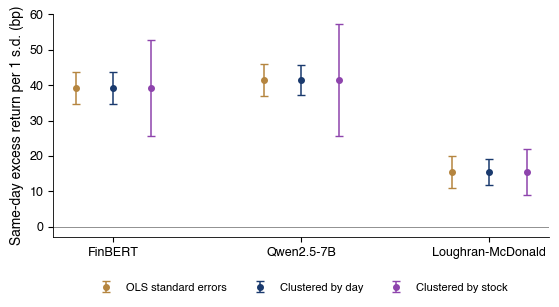

   saved ch15_sem_cluster
              b_bp  se_ols  se_day  se_tic   t_ols   t_day  t_tic        n  \
finbert|r0  39.228   2.309   2.271   6.869  16.988  17.271  5.711  18282.0   
finbert|r1   3.184   2.233   1.990   2.538   1.426   1.600  1.255  18282.0   
finbert|r2  -0.536   2.180   2.153   1.514  -0.246  -0.249 -0.354  18282.0   
lm|r0       15.474   2.325   1.813   3.291   6.657   8.534  4.702  18282.0   
lm|r1       -0.365   2.233   1.710   1.430  -0.164  -0.214 -0.255  18282.0   
lm|r2       -0.026   2.180   1.737   0.875  -0.012  -0.015 -0.029  18282.0   
qwen|r0     41.446   2.307   2.174   8.134  17.965  19.068  5.096  18282.0   
qwen|r1      3.695   2.233   1.984   3.014   1.655   1.862  1.226  18282.0   
qwen|r2      2.315   2.180   1.938   0.959   1.062   1.194  2.414  18282.0   

             G_day  G_tic     r2  
finbert|r0  3434.0   16.0  0.016  
finbert|r1  3434.0   16.0  0.000  
finbert|r2  3434.0   16.0  0.000  
lm|r0       3434.0   16.0  0.002  
lm|r1       3434.0

{
 "1.5B": {
  "pre": {
   "auc": 0.5745556367177989,
   "lo": 0.505968609182546,
   "hi": 0.6406150436017946,
   "n": 296,
   "n_up": 185,
   "mean_up": 0.3604982648648649,
   "mean_down": 0.2962801531531532
  },
  "post": {
   "auc": 0.7192307692307692,
   "lo": 0.4924213286713287,
   "hi": 0.9126984126984127,
   "n": 23,
   "n_up": 13,
   "mean_up": 0.7372707692307693,
   "mean_down": 0.6646426999999999
  }
 },
 "7B": {
  "pre": {
   "auc": 0.6700267835402971,
   "lo": 0.6056984737167468,
   "hi": 0.7349237007541021,
   "n": 296,
   "n_up": 185,
   "mean_up": 0.7316874594594595,
   "mean_down": 0.4336406036036035
  },
  "post": {
   "auc": 0.5307692307692308,
   "lo": 0.2833333333333333,
   "hi": 0.7833578431372548,
   "n": 23,
   "n_up": 13,
   "mean_up": 0.6006488461538462,
   "mean_down": 0.4712244
  }
 },
 "14B": {
  "pre": {
   "auc": 0.6872656440224008,
   "lo": 0.6221625099045155,
   "hi": 0.7525884330897763,
   "n": 296,
   "n_up": 185,
   "mean_up": 0.8101882378378379,
   "

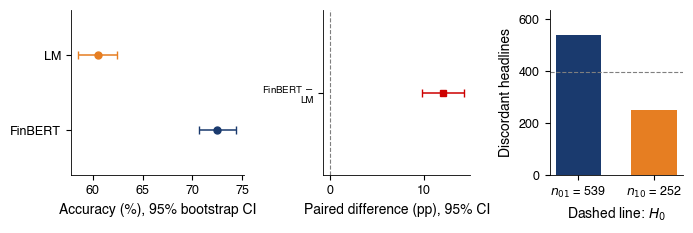

   saved ch15_sem_b1_pairs


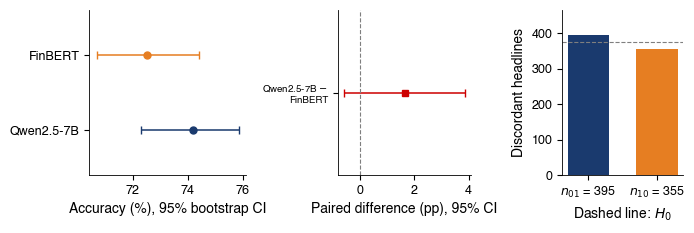

   saved ch15_sem_b2_pairs


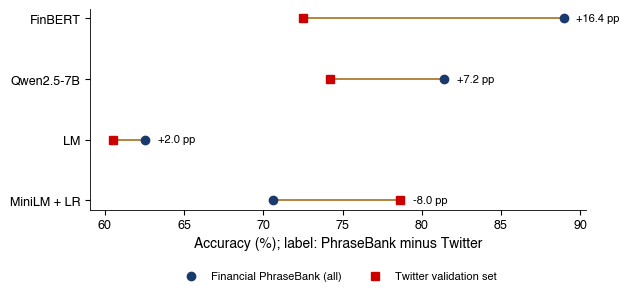

   saved ch15_sem_b3_leakage


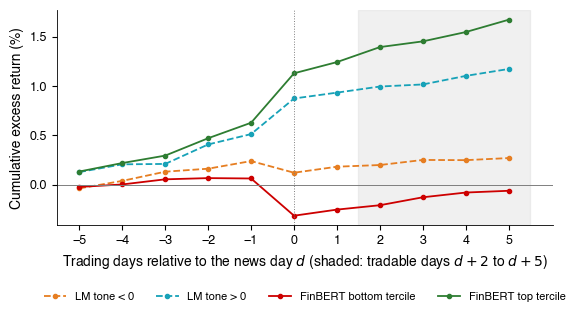

   saved ch15_sem_b6_event


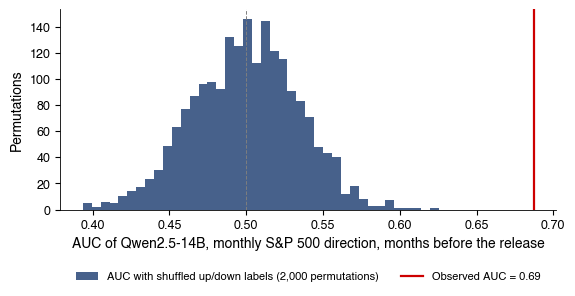

   saved ch15_sem_b7_perm
permutation p: 0.0


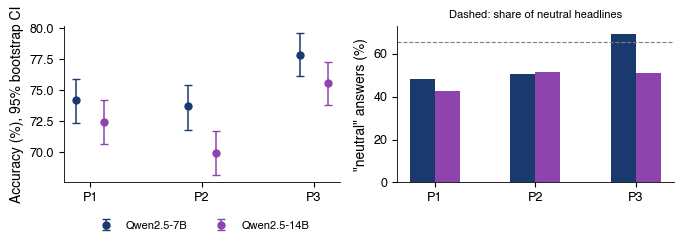

   saved ch15_sem_b8_prompts


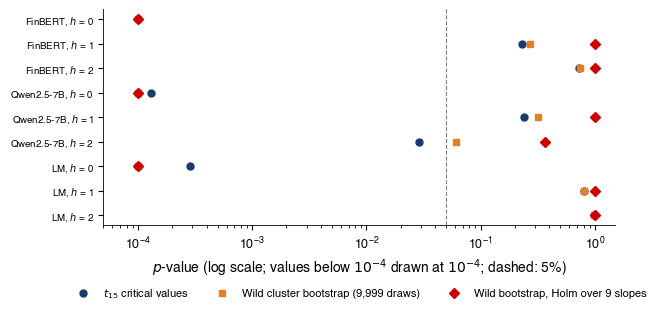

   saved ch15_sem_b10_pvalues


In [7]:
S = {'B1': b_pairs('LM', 'FinBERT'), 'B2': b_pairs('FinBERT', 'Qwen 7B'), 'B3': b_leakage(), 'B8': b_prompts()}
print(json.dumps(jsonable({k: S[k] for k in ('B1', 'B3')}), indent=1))
P, rets = news_panel()
B5 = b_cluster(P)
fig_cluster(B5)
print(pd.DataFrame(B5).T.round(3))
print(json.dumps(jsonable(b_event(P, 'lm')), indent=1))
print(json.dumps(jsonable(b_memory()), indent=1))
fig_pairs()
fig_pairs('B2', ('FinBERT', 'Qwen2.5-7B'), 'ch15_sem_b2_pairs')
fig_leakage()
fig_event_paths(P)
print('permutation p:', fig_perm())
fig_prompts_ci()
VI_PN = (json.load(open(os.path.join(FC_DIR, 'ch15_inference.json'))) if FC_DIR else
         json.load(urllib.request.urlopen(FC_RAW + 'ch15_inference.json')))['panel']['reg']
fig_pvalues(VI_PN)

![ch15_sem_cluster](./ch15_sem_cluster.png)

Output: `ch15_sem_cluster.pdf`

![ch15_sem_b1_pairs](./ch15_sem_b1_pairs.png)

Output: `ch15_sem_b1_pairs.pdf`

![ch15_sem_b2_pairs](./ch15_sem_b2_pairs.png)

Output: `ch15_sem_b2_pairs.pdf`

![ch15_sem_b3_leakage](./ch15_sem_b3_leakage.png)

Output: `ch15_sem_b3_leakage.pdf`

![ch15_sem_b6_event](./ch15_sem_b6_event.png)

Output: `ch15_sem_b6_event.pdf`

![ch15_sem_b7_perm](./ch15_sem_b7_perm.png)

Output: `ch15_sem_b7_perm.pdf`

![ch15_sem_b8_prompts](./ch15_sem_b8_prompts.png)

Output: `ch15_sem_b8_prompts.pdf`

![ch15_sem_b10_pvalues](./ch15_sem_b10_pvalues.png)

Output: `ch15_sem_b10_pvalues.pdf`